# Project 3: Sales & Demand Forecasting
## Notebook 1: EDA & Time Series Decomposition

**Dataset:** Superstore Sales (Kaggle) — 4 years of retail sales across categories and regions

**Goal:** Understand the data's trend, seasonality, and noise before modelling.

In [3]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np

print(pd.__version__)
print(np.__version__)

2.2.2
1.26.4


In [1]:
import pandas as pd
import numpy as np

print(pd.__version__)
print(np.__version__)

2.2.2
1.26.4


In [5]:
import sys

print(sys.executable)

c:\Users\Administrator\SalesForecastingDashboard\.venv\Scripts\python.exe


In [7]:
pip uninstall -y pandas

Found existing installation: pandas 3.0.3
Uninstalling pandas-3.0.3:
  Successfully uninstalled pandas-3.0.3
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


In [8]:
pip uninstall -y pandas

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB 162.5 kB/s eta 0:00:59
   ---------------------------------------- 0.0/9.5 MB 163.8 kB/s eta 0:00:59
   ---------------------------------------- 0.0/9.5 MB 163.8 kB/s eta 0:00:59
   ---------------------------------------- 0.0/9.5 MB 163.8 kB/s eta 0:00:59
   ---------------------------------------- 0.0/9.5 MB 130.7 kB/s eta 0:01:13
   ---------------------------------------- 0.1/9.5 MB 181.6 kB/s eta 0:00:53
   ---------------------------------------- 0.1/9.5 MB 187.3 kB/s eta 0:00:51
   ---------------------------------------- 0.1/9.5 MB 218.5 kB/s eta 0:00:44
   ---------------------------------------- 0.1/9.5 MB 203.4 kB/s eta 0:00:47
   ---------------------------------------- 0.1/9.5 MB 203.4 kB/s eta 0:00:47
    ---------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid')

BASE        = Path(r'C:\Users\Administrator\SalesForecast')
RAW_DIR     = BASE / 'data' / 'raw'
PROC_DIR    = BASE / 'data' / 'processed'
FIG_DIR     = BASE / 'reports' / 'figures'
for d in [PROC_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data
Download Superstore Sales from: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

In [9]:
pip install kagglehub

     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------- ----------------------------- 10.2/40.1 kB ? eta -:--:--
     ------------------- ------------------ 20.5/40.1 kB 320.0 kB/s eta 0:00:01
     ----------------------------- -------- 30.7/40.1 kB 262.6 kB/s eta 0:00:01
     -------------------------------------- 40.1/40.1 kB 238.8 kB/s eta 0:00:00
     ---------------------------------------- 0.0/58.7 kB ? eta -:--:--
     ---------------------------------- ----- 51.2/58.7 kB 1.3 MB/s eta 0:00:01
     ---------------------------------------- 58.7/58.7 kB 1.6 MB/s eta 0:00:00
     ---------------------------------------- 0.0/41.7 kB ? eta -:--:--
     ---------------------------------------- 41.7/41.7 kB 2.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/70.6 kB ? eta -:--:--
   ----------------------- ---------------- 41.0/70.6 kB 960.0 kB/s eta 0:00:01
   ---------------------------------------- 70.6/70.6 kB 764.6 kB/s eta 0:00:00
 


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

100%|██████████| 550k/550k [00:01<00:00, 429kB/s]

Extracting files...
Path to dataset files: C:\Users\Administrator\.cache\kagglehub\datasets\vivek468\superstore-dataset-final\versions\1


In [21]:
import os

print(os.listdir("C:/Users/Administrator/SalesForecastingDashboard"))

['.venv']


In [24]:
import glob

print(glob.glob("C:/Users/Administrator/**/Sample*.csv", recursive=True))

['C:/Users/Administrator\\Downloads\\sample_submission.csv', 'C:/Users/Administrator\\Downloads\\archive (4)\\Sample - Superstore.csv']


In [25]:
import pandas as pd

df = pd.read_csv(
    r"C:/Users/Administrator/Downloads/archive (4)/Sample - Superstore.csv",
    encoding="latin-1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [27]:

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [28]:
# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

print(f'Date range: {df["Order Date"].min()} to {df["Order Date"].max()}')
print(f'Categories: {df["Category"].unique()}')
print(f'Regions: {df["Region"].unique()}')
print(f'Total sales: ${df["Sales"].sum():,.0f}')
df[['Sales','Profit','Quantity']].describe().round(2)

Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00
Categories: ['Furniture' 'Office Supplies' 'Technology']
Regions: ['South' 'West' 'Central' 'East']
Total sales: $2,297,201


,Sales,Profit,Quantity
count,9994.00,9994.00,9994.00
mean,229.86,28.66,3.79
std,623.25,234.26,2.23
min,0.44,-6599.98,1.00
25%,17.28,1.73,2.00
50%,54.49,8.67,3.00
75%,209.94,29.36,5.00
max,22638.48,8399.98,14.00


## 2. Aggregate to Monthly Time Series

In [29]:
# Aggregate total sales by month
monthly = (
    df.set_index('Order Date')
      .resample('MS')['Sales']
      .sum()
      .rename('Total Sales')
)

# By category
cat_monthly = (
    df.groupby(['Order Date', 'Category'])['Sales']
      .sum()
      .unstack('Category')
      .resample('MS')
      .sum()
)

print(f'Monthly series: {len(monthly)} months')
print(f'\nMonthly sales head:')
monthly.head()

Monthly series: 48 months

Monthly sales head:


Order Date
2014-01-01    14236.895
2014-02-01     4519.892
2014-03-01    55691.009
2014-04-01    28295.345
2014-05-01    23648.287
Freq: MS, Name: Total Sales, dtype: float64

## 3. Overall Sales Trend

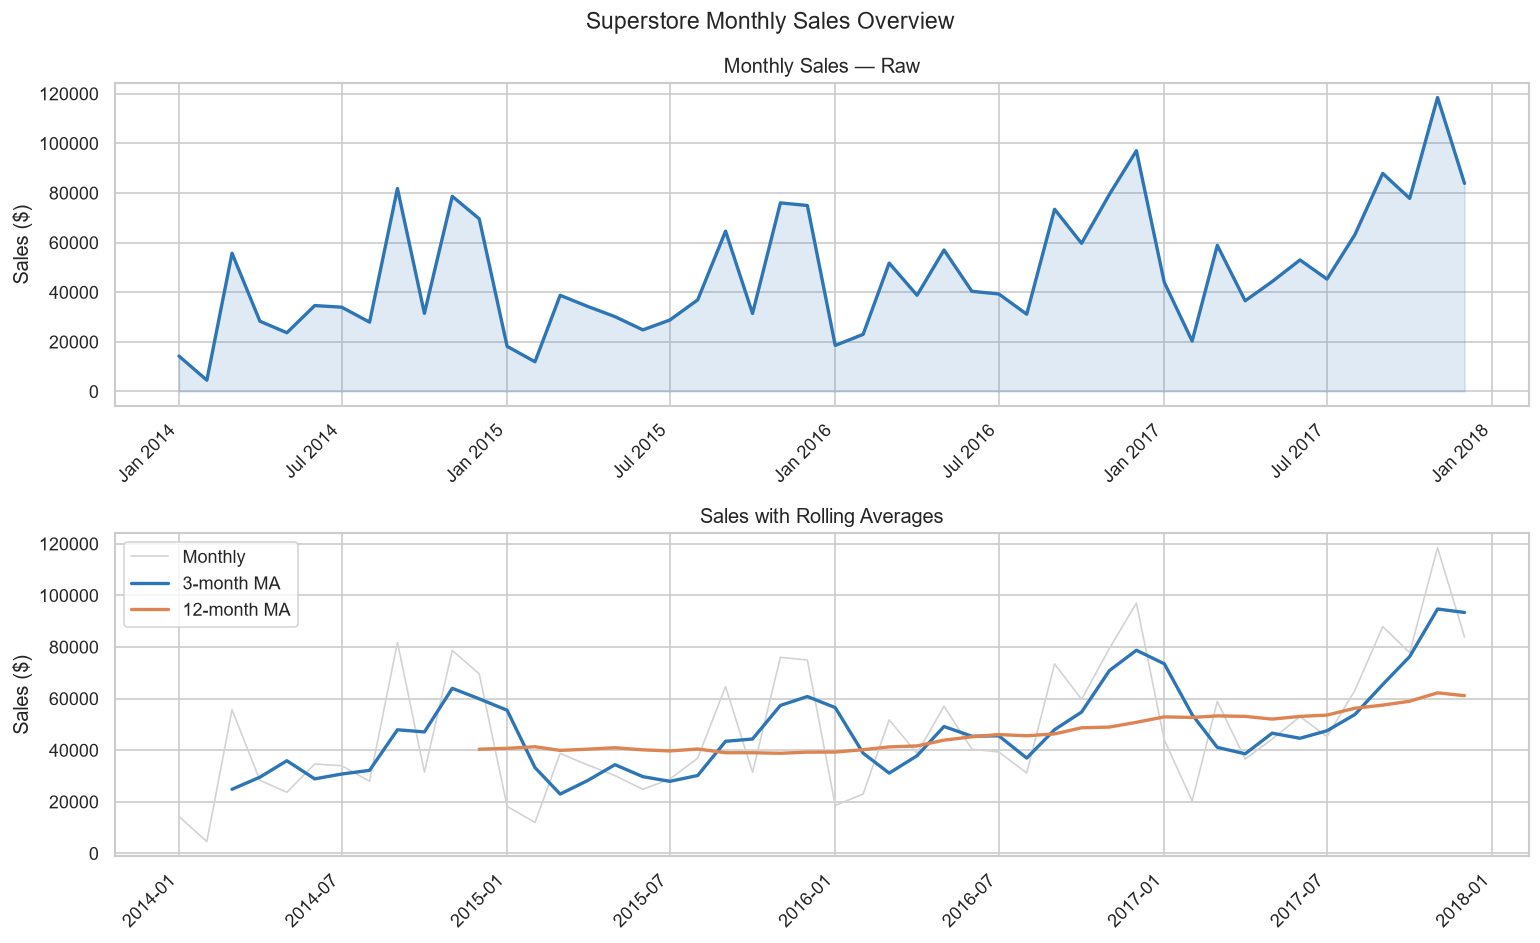

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Raw monthly sales
axes[0].plot(monthly.index, monthly.values, color='#2E75B6', lw=2)
axes[0].fill_between(monthly.index, monthly.values, alpha=0.15, color='#2E75B6')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].set(title='Monthly Sales — Raw', ylabel='Sales ($)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3-month rolling average
roll3  = monthly.rolling(3).mean()
roll12 = monthly.rolling(12).mean()
axes[1].plot(monthly.index, monthly.values, color='lightgray', lw=1, label='Monthly')
axes[1].plot(roll3.index,   roll3.values,   color='#2E75B6', lw=2, label='3-month MA')
axes[1].plot(roll12.index,  roll12.values,  color='#DD8452', lw=2, label='12-month MA')
axes[1].set(title='Sales with Rolling Averages', ylabel='Sales ($)')
axes[1].legend()
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Superstore Monthly Sales Overview', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '01_sales_overview.png', bbox_inches='tight')
plt.show()

## 4. Sales by Category

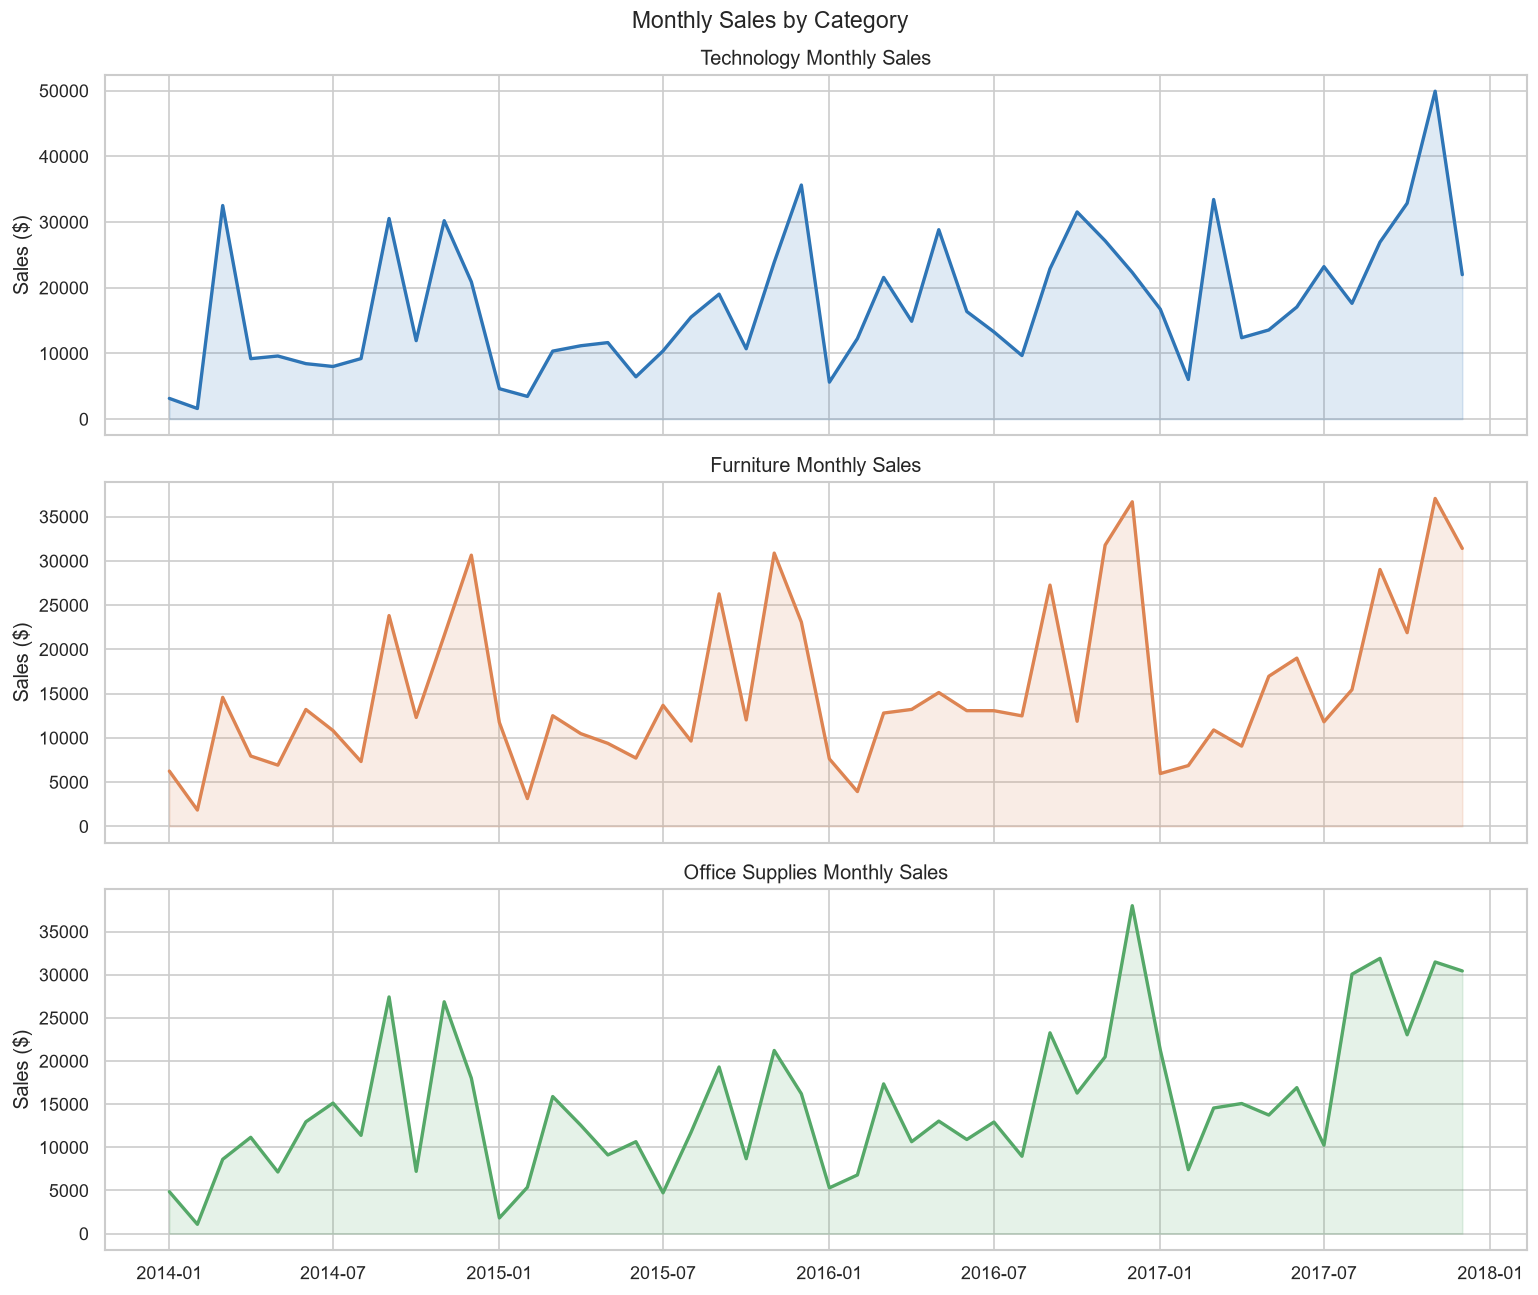

In [31]:
colors = {'Technology': '#2E75B6', 'Furniture': '#DD8452', 'Office Supplies': '#55A868'}

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
for ax, (cat, col) in zip(axes, colors.items()):
    if cat in cat_monthly.columns:
        ax.plot(cat_monthly.index, cat_monthly[cat], color=col, lw=2)
        ax.fill_between(cat_monthly.index, cat_monthly[cat], alpha=0.15, color=col)
        ax.set(title=f'{cat} Monthly Sales', ylabel='Sales ($)')

plt.suptitle('Monthly Sales by Category', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_sales_by_category.png', bbox_inches='tight')
plt.show()

## 5. Seasonality Analysis

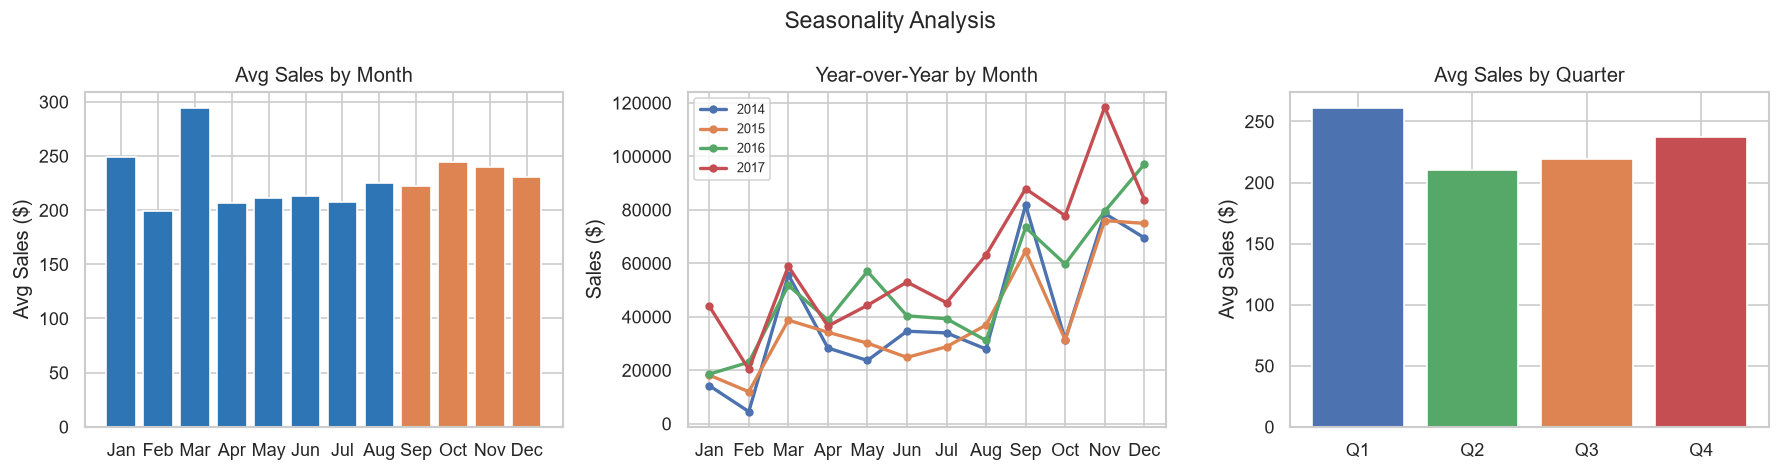

Key insight: Q4 (Oct-Dec) consistently shows the highest sales — holiday season effect.


In [32]:
df['Month']  = df['Order Date'].dt.month
df['Year']   = df['Order Date'].dt.year
df['Quarter']= df['Order Date'].dt.quarter

monthly_avg = df.groupby('Month')['Sales'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Average sales by month
bars = axes[0].bar(range(1,13), monthly_avg.values,
                   color=['#DD8452' if m in [9,10,11,12] else '#2E75B6' for m in range(1,13)],
                   edgecolor='white')
axes[0].set(xticks=range(1,13), xticklabels=month_names, title='Avg Sales by Month')
axes[0].set_ylabel('Avg Sales ($)')

# Year-over-year comparison
yearly = df.groupby(['Year','Month'])['Sales'].sum().unstack('Year')
for year in yearly.columns:
    axes[1].plot(range(1,13), yearly[year].values, marker='o', lw=2, label=str(year), markersize=4)
axes[1].set(xticks=range(1,13), xticklabels=month_names, title='Year-over-Year by Month')
axes[1].set_ylabel('Sales ($)')
axes[1].legend(fontsize=8)

# Sales by quarter
qtly = df.groupby('Quarter')['Sales'].mean()
axes[2].bar(['Q1','Q2','Q3','Q4'], qtly.values,
            color=['#4C72B0','#55A868','#DD8452','#C44E52'], edgecolor='white')
axes[2].set(title='Avg Sales by Quarter')
axes[2].set_ylabel('Avg Sales ($)')

plt.suptitle('Seasonality Analysis', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_seasonality.png', bbox_inches='tight')
plt.show()
print('Key insight: Q4 (Oct-Dec) consistently shows the highest sales — holiday season effect.')

## 6. Time Series Decomposition

Decomposes the series into 3 components:
- **Trend**: long-term direction
- **Seasonality**: repeating patterns (annual cycle)
- **Residuals**: what's left (noise, one-off events)

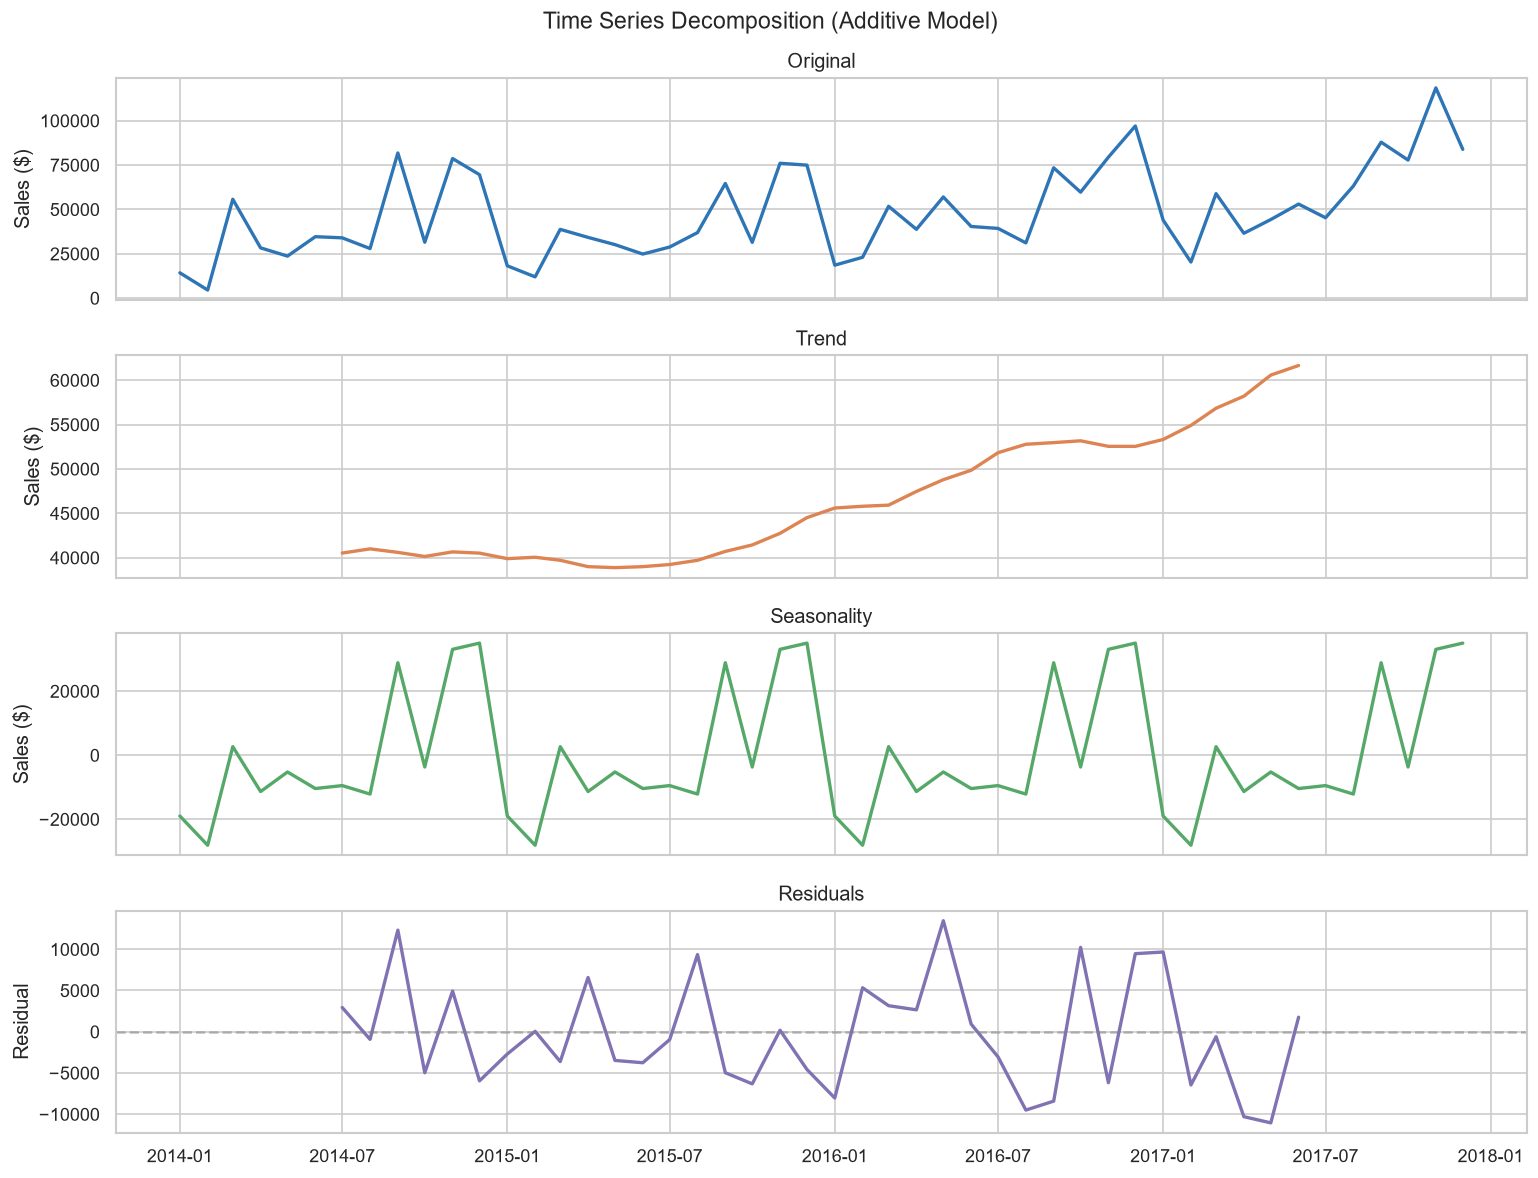

In [33]:
# Need at least 2 full cycles for decomposition
if len(monthly) >= 24:
    decomp = seasonal_decompose(monthly, model='additive', period=12)

    fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
    components = [
        (monthly,           'Original',   '#2E75B6'),
        (decomp.trend,      'Trend',       '#DD8452'),
        (decomp.seasonal,   'Seasonality', '#55A868'),
        (decomp.resid,      'Residuals',   '#8172B3'),
    ]
    for ax, (series, title, color) in zip(axes, components):
        ax.plot(series.index, series.values, color=color, lw=2)
        if title == 'Residuals':
            ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set(title=title)
        ax.set_ylabel('Sales ($)' if title != 'Residuals' else 'Residual')

    plt.suptitle('Time Series Decomposition (Additive Model)', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR / '04_decomposition.png', bbox_inches='tight')
    plt.show()
else:
    print('Need at least 24 months for decomposition.')

## 7. Stationarity Test

SARIMA requires a stationary series (constant mean and variance). We test with the Augmented Dickey-Fuller test.

In [34]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f'=== ADF Test: {name} ===')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value:       {result[1]:.4f}')
    print(f'  Conclusion:    {"STATIONARY" if result[1] < 0.05 else "NON-STATIONARY (needs differencing)"}')
    return result[1] < 0.05

stationary = adf_test(monthly, 'Monthly Sales')
if not stationary:
    print('\nApplying first differencing...')
    monthly_diff = monthly.diff().dropna()
    adf_test(monthly_diff, 'Differenced Sales')

=== ADF Test: Monthly Sales ===
  ADF Statistic: -4.4938
  p-value:       0.0002
  Conclusion:    STATIONARY


## 8. ACF / PACF Plots

Used to identify the order (p, q) parameters for SARIMA.

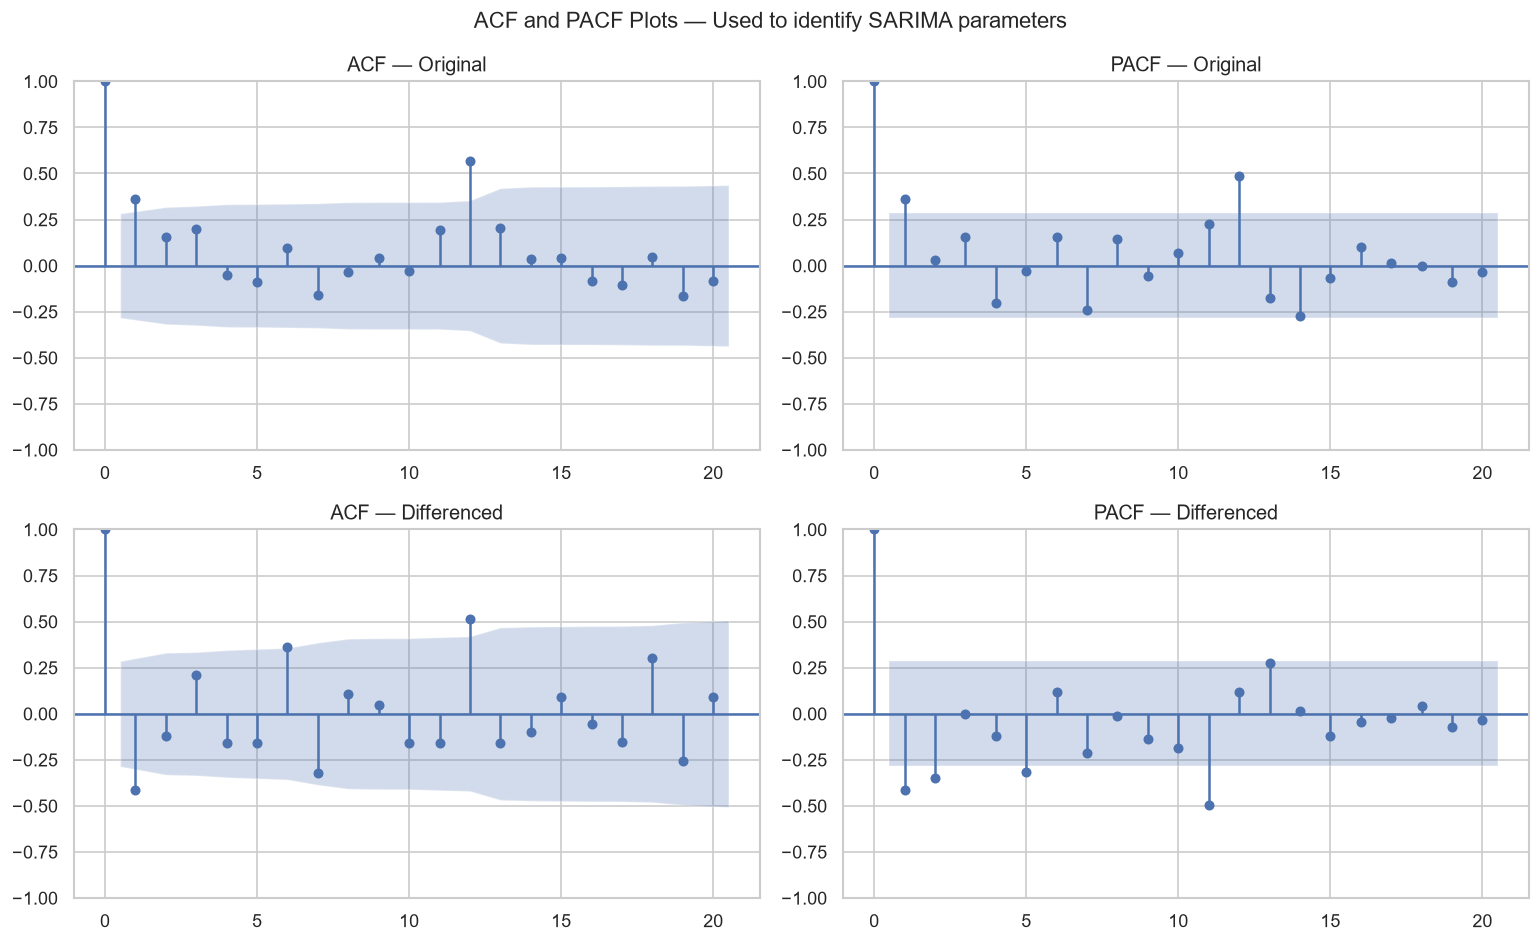

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

plot_acf(monthly.dropna(),            ax=axes[0,0], lags=20, title='ACF — Original')
plot_pacf(monthly.dropna(),           ax=axes[0,1], lags=20, title='PACF — Original')
plot_acf(monthly.diff().dropna(),     ax=axes[1,0], lags=20, title='ACF — Differenced')
plot_pacf(monthly.diff().dropna(),    ax=axes[1,1], lags=20, title='PACF — Differenced')

plt.suptitle('ACF and PACF Plots — Used to identify SARIMA parameters', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_acf_pacf.png', bbox_inches='tight')
plt.show()

## 9. Save Processed Data

In [37]:
# Save monthly series for modelling notebooks
monthly.to_csv(PROC_DIR / 'monthly_sales.csv')
cat_monthly.to_csv(PROC_DIR / 'monthly_sales_by_category.csv')

# Summary stats
yoy_growth = (monthly.resample('YE').sum().pct_change() * 100).round(1)
print('Year-over-Year Growth:')
print(yoy_growth.to_string())

peak_month = monthly_avg.idxmax()
slowest_month = monthly_avg.idxmin()
print(f'\nPeak month: {month_names[peak_month-1]}')
print(f'Slowest month: {month_names[slowest_month-1]}')
print('\n✅  EDA complete. Saved to data/processed/')
print('Next: open 02_SARIMA.ipynb')

Year-over-Year Growth:
Order Date
2014-12-31     NaN
2015-12-31    -2.8
2016-12-31    29.5
2017-12-31    20.4
Freq: YE-DEC

Peak month: Mar
Slowest month: Feb

✅  EDA complete. Saved to data/processed/
Next: open 02_SARIMA.ipynb
